In [1]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import root_mean_squared_error
import os
os.chdir("C:/Users/PGCP-AI/ML/MachineLearning/Datasets")

In [2]:
df = pd.read_csv('Electric_Production.csv')
df.columns

Index(['DATE', 'IPG2211A2N'], dtype='object')

In [3]:
result = adfuller(df['IPG2211A2N'], maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 0.2997901766156502
Time Series is not Stationary


In [4]:
diff = df["IPG2211A2N"].diff().iloc[1:]
result = adfuller(diff, maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 0.0
Time Series is Stationary


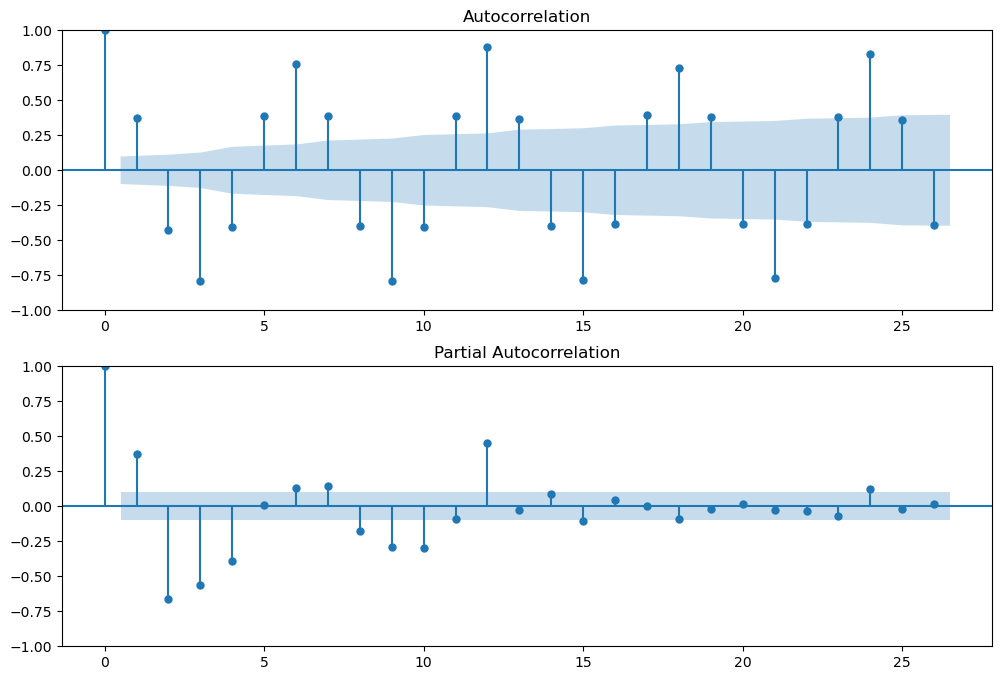

In [5]:
fig, ax = plt.subplots(2, 1, figsize = (12,8))
plot_acf(diff, ax = ax[0])
plot_pacf(diff, ax = ax[1])
plt.show()

In [7]:
y_train = df['IPG2211A2N'].iloc[:-12]
y_test = df['IPG2211A2N'].iloc[-12:]

In [28]:
model = ARIMA(y_train, order = (3,1,2))
model_fit = model.fit()

C:\Users\PGCP-AI\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
predictions = model_fit.predict(start = len(y_train), end = len(y_train) + len(y_test) -1, dynamic = False)
rmse = root_mean_squared_error(y_test, predictions)

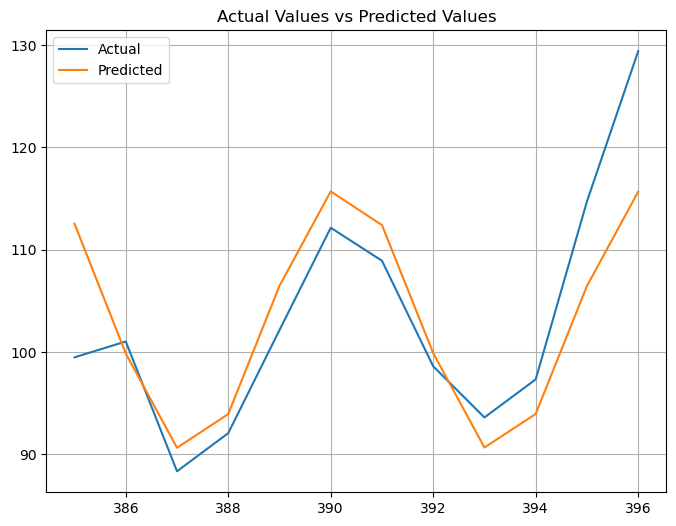

In [30]:
plt.figure(figsize=(8,6))
plt.plot(df['IPG2211A2N'][-12:],label='Actual')
plt.plot(predictions,label='Predicted')
plt.title('Actual Values vs Predicted Values')
plt.legend()
plt.grid()
plt.show()

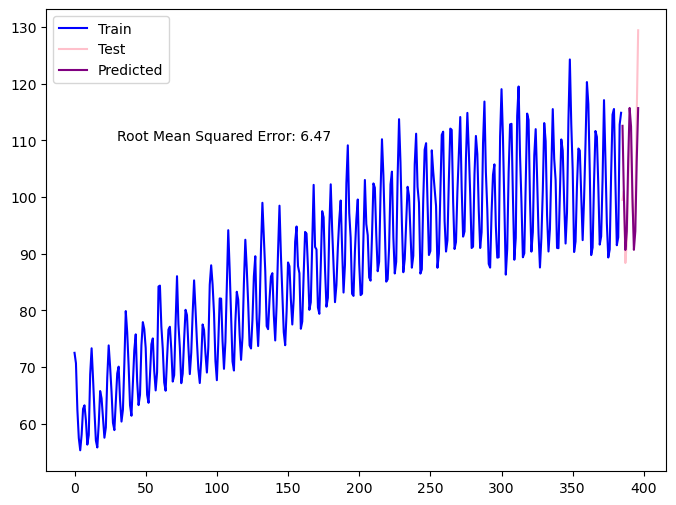

In [31]:
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
predictions.plot(color='purple',label='Predicted')
plt.text(30,110,f"Root Mean Squared Error: {rmse:.2f}")
plt.legend()
plt.show()

In [16]:
from pmdarima.arima import auto_arima

In [17]:
model = auto_arima(y_train, trace = True, error_Action = 'ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.86 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2657.357, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2599.753, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2531.251, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2655.436, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2531.973, Time=0.13 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2433.235, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2400.984, Time=0.36 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2353.950, Time=0.39 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=2353.710, Time=0.35 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=2336.712, Time=0.46 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=2337.090, Time=0.65 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=2263.899, Time=0.64 sec
 ARIMA(1,1,5)(0,0,0)[0] intercept   : AIC=2253.412, Time=0.95 sec
 ARIMA(2,1,5)(0,0,0)[0] intercept   : 

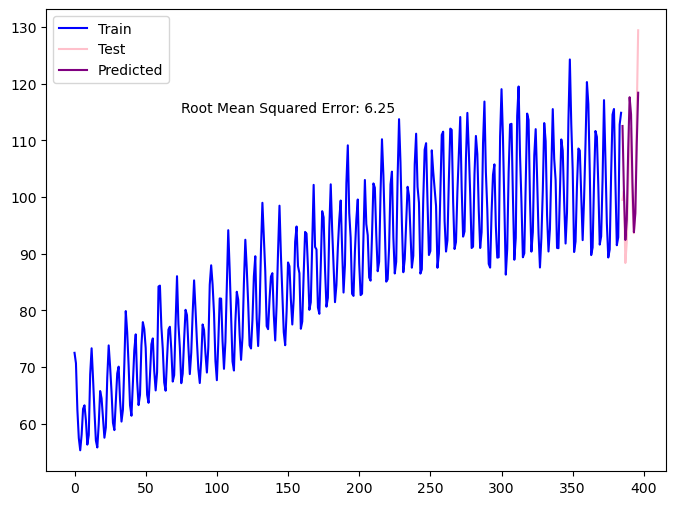

In [20]:
forecast_auto =  model.predict(n_periods=len(y_test))
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
forecast_auto.plot(color='purple',label='Predicted')
plt.text(75,115,f"Root Mean Squared Error: {root_mean_squared_error(y_test,forecast_auto):.2f}")
plt.legend()
plt.show()

In [21]:
s_model = auto_arima(y_train, trace = True, error_Action = 'ignore', seasonal=True, m = 12, suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.91 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2657.357, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2308.651, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2655.436, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=2531.251, Time=0.09 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1840.978, Time=1.34 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1957.997, Time=0.43 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=1841.393, Time=2.63 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1842.078, Time=3.13 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=2229.577, Time=0.96 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=1916.667, Time=1.25 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=inf, Time=3.60 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1866.130, Time=0.87 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept

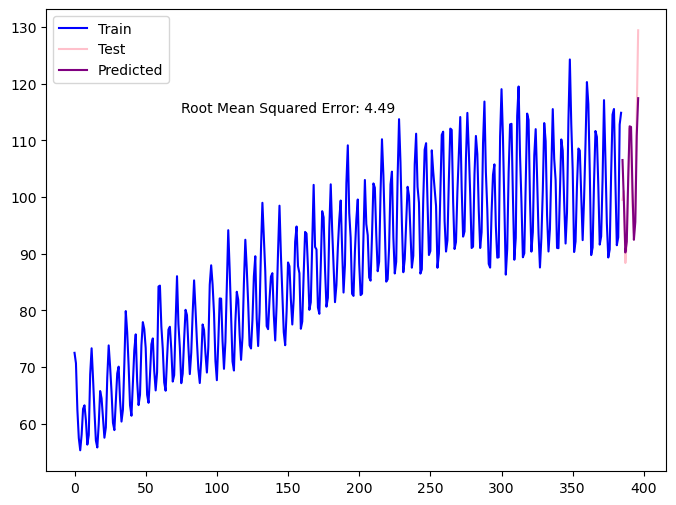

In [22]:
forecast =  s_model.predict(n_periods=len(y_test))
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
forecast.plot(color='purple',label='Predicted')
plt.text(75,115,f"Root Mean Squared Error: {root_mean_squared_error(y_test,forecast):.2f}")
plt.legend()
plt.show()